<a href="https://colab.research.google.com/github/yeonsub/Learning_Material_for_Creation/blob/main/Clip_latent_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import os
import cv2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
import itertools
from itertools import chain
import scipy

import pandas as pd

from tqdm.autonotebook import tqdm
import albumentations as A

import timm
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer

In [ ]:
!pip install kaggle --upgrade

from google.colab import userdata

# Colab 비밀에서 Kaggle 사용자 이름과 키를 불러옵니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

### For Flickr 8k
!kaggle datasets download -d adityajn105/flickr8k
!unzip flickr8k.zip > /dev/null 2>&1
dataset = "8k"


### For Flickr 30k
# !kaggle datasets download -d hsankesara/flickr-image-dataset
# !unzip flickr-image-dataset.zip
# dataset = "30k"

In [4]:
if dataset == "8k":
  df = pd.read_csv("captions.txt")
  df['id'] = [id_ for id_ in range(df.shape[0] // 5) for _ in range(5)]
  df.to_csv("captions.csv", index=False)
  df = pd.read_csv("captions.csv")
  image_path = "/content/Images"
  captions_path = "/content"
elif dataset == "30k":
  df = pd.read_csv("/content/flickr30k_images/results.csv", delimiter="|")
  df.columns = ['image', 'caption_number', 'caption']
  df['caption'] = df['caption'].str.lstrip()
  df['caption_number'] = df['caption_number'].str.lstrip()
  df.loc[19999, 'caption_number'] = "4"
  df.loc[19999, 'caption'] = "A dog runs across the grass ."
  ids = [id_ for id_ in range(len(df) // 5) for _ in range(5)]
  df['id'] = ids
  df.to_csv("captions.csv", index=False)
  image_path = "/content/flickr30k_images/flickr30k_images"
  captions_path = "/content"

df.head()

,image,caption,id
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,0
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,0
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,0
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,0
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,0


In [24]:
class CFG:
    debug = False
    image_path = image_path
    captions_path = captions_path
    batch_size = 32
    num_workers = 2
    head_lr = 1e-3
    image_encoder_lr = 1e-4
    text_encoder_lr = 1e-5
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 1
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_name = 'resnet50'
    image_embedding = 2048
    text_encoder_model = "distilbert-base-uncased"
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_length = 200

    pretrained = True # for both image encoder and text encoder
    trainable = True # for both image encoder and text encoder
    temperature = 1.0

    # image size
    size = 224

    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256
    dropout = 0.1

In [7]:
class AvgMeter:
    def __init__(self, name="Metric"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


In [17]:
class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self, image_filenames, captions, tokenizer, transforms):
        """
        image_filenames and cpations must have the same length; so, if there are
        multiple captions for each image, the image_filenames must have repetitive
        file names
        """

        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.encoded_captions = tokenizer(
            list(captions), padding=True, truncation=True, max_length=CFG.max_length
        )
        self.transforms = transforms

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx])
            for key, values in self.encoded_captions.items()
        }

        image = cv2.imread(f"{CFG.image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        item['image'] = torch.tensor(image).permute(2, 0, 1).float()
        item['caption'] = self.captions[idx]

        return item


    def __len__(self):
        return len(self.captions)



def get_transforms(mode="train"):
    if mode == "train":
        return A.Compose(
            [
                A.Resize(CFG.size, CFG.size),
                A.Normalize(max_pixel_value=255.0),
            ]
        )
    else:
        return A.Compose(
            [
                A.Resize(CFG.size, CFG.size),
                A.Normalize(max_pixel_value=255.0),
            ]
        )

In [9]:
class ImageEncoder(nn.Module):
    """
    Encode images to a fixed size vector
    """

    def __init__(
        self, model_name=CFG.model_name, pretrained=CFG.pretrained, trainable=CFG.trainable
    ):
        super().__init__()
        self.model = timm.create_model(
            model_name, pretrained, num_classes=0, global_pool="avg"
        )
        for p in self.model.parameters():
            p.requires_grad = trainable

    def forward(self, x):
        return self.model(x)

In [10]:
class TextEncoder(nn.Module):
    def __init__(self, model_name=CFG.text_encoder_model, pretrained=CFG.pretrained, trainable=CFG.trainable):
        super().__init__()
        if pretrained:
            self.model = DistilBertModel.from_pretrained(model_name)
        else:
            self.model = DistilBertModel(config=DistilBertConfig())

        for p in self.model.parameters():
            p.requires_grad = trainable

        # we are using the CLS token hidden representation as the sentence's embedding
        self.target_token_idx = 0

    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state
        return last_hidden_state[:, self.target_token_idx, :]

In [11]:
class ProjectionHead(nn.Module):
    def __init__(
        self,
        embedding_dim,
        projection_dim=CFG.projection_dim,
        dropout=CFG.dropout
    ):
        super().__init__()
        self.projection = nn.Linear(embedding_dim, projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)

    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        x = self.layer_norm(x)
        return x

In [12]:
class CLIPModel(nn.Module):
    def __init__(
        self,
        temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding,
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(embedding_dim=text_embedding)
        self.temperature = temperature

    def forward(self, batch):
        # Getting Image and Text Features
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        # Getting Image and Text Embeddings (with same dimension)
        image_embeddings = self.image_projection(image_features)
        text_embeddings = self.text_projection(text_features)

        # Calculating the Loss
        logits = (text_embeddings @ image_embeddings.T) / self.temperature
        images_similarity = image_embeddings @ image_embeddings.T
        texts_similarity = text_embeddings @ text_embeddings.T
        targets = F.softmax(
            (images_similarity + texts_similarity) / 2 * self.temperature, dim=-1
        )
        texts_loss = cross_entropy(logits, targets, reduction='none')
        images_loss = cross_entropy(logits.T, targets.T, reduction='none')
        loss =  (images_loss + texts_loss) / 2.0 # shape: (batch_size)
        return loss.mean()


def cross_entropy(preds, targets, reduction='none'):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    if reduction == "none":
        return loss
    elif reduction == "mean":
        return loss.mean()

In [13]:
# A simple Example

batch_size = 4
dim = 256
embeddings = torch.randn(batch_size, dim)
out = embeddings @ embeddings.T
print(F.softmax(out, dim=-1))

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


In [14]:
def make_train_valid_dfs():
    dataframe = pd.read_csv(f"{CFG.captions_path}/captions.csv")
    max_id = dataframe["id"].max() + 1 if not CFG.debug else 100
    image_ids = np.arange(0, max_id)
    np.random.seed(42)
    valid_ids = np.random.choice(
        image_ids, size=int(0.2 * len(image_ids)), replace=False
    )
    train_ids = [id_ for id_ in image_ids if id_ not in valid_ids]
    train_dataframe = dataframe[dataframe["id"].isin(train_ids)].reset_index(drop=True)
    valid_dataframe = dataframe[dataframe["id"].isin(valid_ids)].reset_index(drop=True)
    return train_dataframe, valid_dataframe


def build_loaders(dataframe, tokenizer, mode):
    transforms = get_transforms(mode=mode)
    dataset = CLIPDataset(
        dataframe["image"].values,
        dataframe["caption"].values,
        tokenizer=tokenizer,
        transforms=transforms,
    )
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        num_workers=CFG.num_workers,
        shuffle=True if mode == "train" else False,
    )
    return dataloader

In [15]:
def train_epoch(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(train_loader, total=len(train_loader))
    for batch in tqdm_object:
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == "batch":
            lr_scheduler.step()

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(train_loss=loss_meter.avg, lr=get_lr(optimizer))
    return loss_meter


def valid_epoch(model, valid_loader):
    loss_meter = AvgMeter()

    tqdm_object = tqdm(valid_loader, total=len(valid_loader))
    for batch in tqdm_object:
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(valid_loss=loss_meter.avg)
    return loss_meter


def main():
    train_df, valid_df = make_train_valid_dfs()
    tokenizer = DistilBertTokenizer.from_pretrained(CFG.text_tokenizer)
    train_loader = build_loaders(train_df, tokenizer, mode="train")
    valid_loader = build_loaders(valid_df, tokenizer, mode="valid")


    model = CLIPModel().to(CFG.device)
    params = [
        {"params": model.image_encoder.parameters(), "lr": CFG.image_encoder_lr},
        {"params": model.text_encoder.parameters(), "lr": CFG.text_encoder_lr},
        {"params": itertools.chain(
            model.image_projection.parameters(), model.text_projection.parameters()
        ), "lr": CFG.head_lr, "weight_decay": CFG.weight_decay}
    ]
    optimizer = torch.optim.AdamW(params, weight_decay=0.)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=CFG.patience, factor=CFG.factor
    )
    step = "epoch"

    best_loss = float('inf')
    for epoch in range(CFG.epochs):
        print(f"Epoch: {epoch + 1}")
        model.train()
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler, step)
        model.eval()
        with torch.no_grad():
            valid_loss = valid_epoch(model, valid_loader)

        if valid_loss.avg < best_loss:
            best_loss = valid_loss.avg
            torch.save(model.state_dict(), "best.pt")
            print("Saved Best Model!")

        lr_scheduler.step(valid_loss.avg)

In [ ]:
main()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch: 1


  0%|          | 0/1012 [00:00<?, ?it/s]

In [ ]:
def get_image_embeddings(valid_df, model_path):
    tokenizer = DistilBertTokenizer.from_pretrained(CFG.text_tokenizer)
    valid_loader = build_loaders(valid_df, tokenizer, mode="valid")

    model = CLIPModel().to(CFG.device)
    model.load_state_dict(torch.load(model_path, map_location=CFG.device))
    model.eval()

    valid_image_embeddings = []
    with torch.no_grad():
        for batch in tqdm(valid_loader):
            image_features = model.image_encoder(batch["image"].to(CFG.device))
            image_embeddings = model.image_projection(image_features)
            valid_image_embeddings.append(image_embeddings)
    return model, torch.cat(valid_image_embeddings)

In [ ]:
_, valid_df = make_train_valid_dfs()
model, image_embeddings = get_image_embeddings(valid_df, "best.pt")

In [ ]:
def find_matches(model, image_embeddings, query, image_filenames, n=9):
    tokenizer = DistilBertTokenizer.from_pretrained(CFG.text_tokenizer)
    encoded_query = tokenizer([query])
    batch = {
        key: torch.tensor(values).to(CFG.device)
        for key, values in encoded_query.items()
    }
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(text_features)

    image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
    text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
    dot_similarity = text_embeddings_n @ image_embeddings_n.T

    values, indices = torch.topk(dot_similarity.squeeze(0), n * 5)
    matches = [image_filenames[idx] for idx in indices[::5]]

    _, axes = plt.subplots(3, 3, figsize=(10, 10))
    for match, ax in zip(matches, axes.flatten()):
        image = cv2.imread(f"{CFG.image_path}/{match}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.axis("off")

    plt.show()

In [ ]:
query = input("검색할 이미지에 대한 텍스트 설명을 입력하세요: ")
find_matches(model,
             image_embeddings,
             query=query,
             image_filenames=valid_df['image'].values,
             n=9)

# Latent Flow Model


### Conceptual Changes for Flow Matching

To switch from a Diffusion Model to a Flow Matching model, we need to adapt several components:

1.  **Model Architecture**: The current U-Net (`ConditionalTimeEmbeddingModel`) might be adaptable, but its output interpretation will change. Instead of predicting noise `eps`, it will need to predict a vector field `v`.
2.  **Variance Schedule (Path Definition)**: Instead of `alpha_prod` for diffusion, we'll define a simple *conditional probability path* $p_t(x | x_0, x_1)$ (or *reference flow*) that smoothly interpolates between a data point $x_0$ and a noisy point $x_1$. A common choice is a straight path:
    $$ x_t = (1 - t)x_0 + tx_1 $$
3.  **Loss Function**: The `do_step` function will be entirely different. The Flow Matching loss aims to minimize the squared difference between the neural network's predicted vector field and the true tangent vector of the conditional path. For a straight path, the target vector field is often $(x_1 - x_0)$ or a scaled version of it.
    $$ L = E_{t \sim U(0,1), x_0 \sim p_{data}, x_1 \sim p_{noise}} [ \| v_{\theta}(x_t, t) - (x_1 - x_0) \|^2 ] $$
4.  **Sampling (Inference)**: Instead of iterative denoising, sampling involves numerically integrating the learned vector field $v_{\theta}(x, t)$ from $t=1$ (noise) down to $t=0$ (data) using an ODE solver (e.g., Euler, Runge-Kutta).


## Data Loading and Initialization

Start by setting up some plotting defaults

In [ ]:
plot_alpha = 0.0
is_dark = True
if is_dark:
    pyplot_context = 'dark_background'
    binary_cmap = LinearSegmentedColormap.from_list(name='binary_alpha', colors=[(0,0,0,plot_alpha), (1,1,1,1)])
else:
    pyplot_context = 'default'
    binary_cmap = LinearSegmentedColormap.from_list(name='binary_alpha', colors=[(1,1,1,1), (0,0,0,plot_alpha)])

We then check if cuda is available and disable gradient calculations for the time being as we explore.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Flow Matching Model Setup

### Variational Encoder and Latent Variable Dataset

### 모델을 사용하여 잠재 공간의 데이타 생성 (Flickr images)
Now we need to create the dataset and dataloaders for training the VAE on Flickr images, and then generate the latent variables.

In [ ]:
class FlickrVAEImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_filenames, image_path, transforms):
        self.image_filenames = image_filenames
        self.image_path = image_path
        self.transforms = transforms

    def __getitem__(self, idx):
        image = cv2.imread(f"{self.image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        # Normalize to [-1, 1] range
        image = (image / 255.0 - 0.5) * 2.0
        return image.permute(2, 0, 1).float() # HWC to CHW

    def __len__(self):
        return len(self.image_filenames)


def get_vae_transforms(image_size):
    return A.Compose(
        [
            A.Resize(image_size, image_size, always_apply=True),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), max_pixel_value=255.0, always_apply=True), # Normalize to [-1, 1]
        ]
    )

# Assuming train_df and valid_df are already defined from the CLIP setup
# and image_path from CFG is available
train_df, valid_df = make_train_valid_dfs() # Re-use the function from CLIP setup

vae_train_dataset = FlickrVAEImageDataset(
    image_filenames=train_df['image'].values,
    image_path=CFG.image_path,
    transforms=get_vae_transforms(vae_image_size)
)
vae_val_dataset = FlickrVAEImageDataset(
    image_filenames=valid_df['image'].values,
    image_path=CFG.image_path,
    transforms=get_vae_transforms(vae_image_size)
)

vae_train_loader = torch.utils.data.DataLoader(
    vae_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=CFG.num_workers # Re-use num_workers from CFG
)
vae_val_loader = torch.utils.data.DataLoader(
    vae_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=CFG.num_workers
)

# Prepare latent data for flow matching model (after VAE training)
encoder.eval()

# Train data latents
lat_train = []
with torch.no_grad():
    for batch in tqdm(vae_train_loader, desc="Generating train latents"):
        x = batch.to(device)
        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        lat_train.append(z.cpu())

lat_train = torch.cat(lat_train)

# Validation data latents
lat_val = []
with torch.no_grad():
    for batch in tqdm(vae_val_loader, desc="Generating validation latents"):
        x = batch.to(device)
        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        lat_val.append(z.cpu())

lat_val = torch.cat(lat_val)

#VAE 모델


In [ ]:
class ConvBlock(torch.nn.Module):
    def __init__(self, fin, fout, *args, **kwargs):
        super(ConvBlock, self).__init__()
        self._conv = torch.nn.Conv2d(fin, fout, *args, **kwargs)
        self._norm = torch.nn.BatchNorm2d(fout)
        self._relu = torch.nn.LeakyReLU()

    def forward(self, x):
        return self._relu(self._norm(self._conv(x)))

class ConvEncoder(torch.nn.Module):
    def __init__(self, features):
        super(ConvEncoder, self).__init__()

        layers   = []
        for i in range(len(features)-1):
            fi = features[i]
            fo = features[i+1]
            if i > 0:
                layers.append(torch.nn.Sequential(
                    torch.nn.MaxPool2d(2),
                    ConvBlock(fi, fo, 3, padding='same'),
                    ConvBlock(fo, fo, 3, padding='same'),
                ))
            else:
                layers.append(torch.nn.Sequential(
                    ConvBlock(fi, fo, 3, padding='same'),
                    ConvBlock(fo, fo, 3, padding='same'),
                ))
        self.features = features
        self.layers = torch.nn.ModuleList(layers)


    def forward(self, x):
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

class ConvDecoder(torch.nn.Module):
    def __init__(self, features):
        super(ConvDecoder, self).__init__()

        layers = []
        for i in range(len(features)-1):
            layer = []

            fi = features[i]
            fo = features[i+1]

            if i > 0:
                layer += [
                    torch.nn.Upsample(scale_factor=2),#, mode='bilinear'),
                    ConvBlock(fi, fi, 3, padding='same'),
                ]

            if i < len(features)-2:
                layer += [
                    ConvBlock(fi, fi, 3, padding='same'),
                    ConvBlock(fi, fo, 3, padding='same'),
                ]
            else:
                layer += [
                    ConvBlock(fi, fi, 3, padding='same'),
                    torch.nn.Conv2d(fi, fo, 3, padding='same'),
                ]


            layers.append(torch.nn.Sequential(*layer))

        self.layers = torch.nn.ModuleList(layers)


    def forward(self, x):
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

Let's define some parameters for the VAE

In [ ]:
features = [3, 16, 32, 64] # Changed input channels from 1 to 3 for RGB images
latent_channels = 2
batch_size    = 128
learning_rate = 1e-3
num_epochs    = 200

# Assuming Flickr images are used, we need to define an image size for VAE
# Let's set a smaller image size for the VAE for computational efficiency
# and compatibility with the original VAE's downsampling capabilities.
vae_image_size = 64 # Changed from 32 to 64 for better detail

latent_resolution = vae_image_size // (1 << (len(features) - 1)) # Divide by 2^(num_pooling_layers)
latent_shape = (latent_channels, latent_resolution, latent_resolution)

encoder = ConvEncoder(features + [2 * latent_channels,])
decoder = ConvDecoder([latent_channels,] + features[::-1])

### 기존 학습된 VAE 활용
If you have already trained the VAE, load it. Be sure you skip the following training cells, otherwise you'll have to reload it.

In [ ]:
# # If your VAE is saved to the local drive, you can skip loading it from your google drive.
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Colab Notebooks/autoencoder/variational_encoder.pt" .
!cp "/content/drive/MyDrive/Colab Notebooks/autoencoder/variational_decoder.pt" .

print('Number of parameters:', np.sum([torch.numel(x) for x in list(chain(encoder.parameters(),decoder.parameters()))]))

encoder.load_state_dict(torch.load('variational_encoder.pt', map_location=device))
decoder.load_state_dict(torch.load('variational_decoder.pt', map_location=device))
encoder = encoder.to(device)
decoder = decoder.to(device)

Mounted at /content/drive
Number of parameters: 196867


### 없으면 VAE 생성 후 학습
Let us now create the VAE and train it.

In [ ]:
optimizer = torch.optim.Adam(chain(encoder.parameters(), decoder.parameters()), learning_rate)

print('Number of parameters:', np.sum([torch.numel(x) for x in list(chain(encoder.parameters(),decoder.parameters()))]))

encoder = encoder.to(device)
decoder = decoder.to(device)

Number of parameters: 196867


In [ ]:
print_every = 10
# Use vae_train_loader instead of iterating manually over x_train

avg_loss = 0.0
mean_rec = 0.0
mean_kl  = 0.0
for i in range(num_epochs):
    encoder.train()
    decoder.train()
    tqdm_object = tqdm(vae_train_loader, desc=f"Epoch {i+1} (VAE Train)", leave=False)
    for batch_idx, x in enumerate(tqdm_object):
        x = x.to(device)

        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        new_x = decoder(z)

        # Reconstruction loss for 3 channels
        reconstruction_loss = torch.sum((new_x - x)**2, dim=[1,2,3])
        sigma2 = sigma**2
        kl_loss = 0.5 * torch.sum(sigma2 + mu**2 - torch.log(sigma2) - 1.0, dim=[1,2,3])
        loss = reconstruction_loss + kl_loss
        loss = torch.mean(loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()
        mean_rec += torch.mean(reconstruction_loss).item()
        mean_kl  += torch.mean(kl_loss).item()

    num_batches = len(vae_train_loader)
    avg_loss /= num_batches
    mean_rec /= num_batches
    mean_kl  /= num_batches

    if (i + 1) % print_every == 0:
      print(f"Epoch {i+1}: Loss = {avg_loss:.4f}, Rec_Loss = {mean_rec:.4f}, KL_Loss = {mean_kl:.4f}")
      avg_loss = 0.0
      mean_rec = 0.0
      mean_kl  = 0.0

9 63.445454 29.456955 33.988533
19 63.201435 29.326538 33.87492
29 63.012573 29.239817 33.77273
39 62.828575 29.156393 33.672318
49 62.630898 29.053345 33.577473
59 66.54348 29.256145 37.287365
69 65.7175 28.403986 37.313587
79 64.89412 28.678528 36.21555
89 64.48665 28.80227 35.684307
99 66.067276 28.368275 37.69888


Let's now save the model, and copy the saved model to your google drive.

In [ ]:
torch.save(encoder.state_dict(), 'variational_encoder.pt')
torch.save(decoder.state_dict(), 'variational_decoder.pt')

# Optionally, copy the model to your google drive so you can retrieve it later.
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/autoencoder/', exist_ok=True)
!cp variational_encoder.pt "/content/drive/MyDrive/Colab Notebooks/autoencoder/"
!cp variational_decoder.pt "/content/drive/MyDrive/Colab Notebooks/autoencoder/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Let's make sure that our VAE can reconstruct Flickr images. Let's plot a few original and reconstructed Flickr images.

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(10, 5))
perm = torch.randperm(len(vae_val_dataset))[:8]
d = torch.stack([vae_val_dataset[i] for i in perm]).to(device)

with torch.no_grad():
    encoder.eval()
    decoder.eval()

    mu_sigma = encoder(d)
    mu    = mu_sigma[:,:latent_channels,:,:]
    sigma = mu_sigma[:,latent_channels:,:,:]
    z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu

    pred = decoder(z)
    lat  = z

# Denormalize images for plotting from [-1, 1] to [0, 1]
def denormalize_image(img_tensor):
    return ((img_tensor / 2.0) + 0.5).permute(0, 2, 3, 1).cpu().numpy()

original_images = denormalize_image(d)
reconstructed_images = denormalize_image(pred)
latent_maps = lat.cpu().numpy()

for i in range(8):
    axes[0, i].imshow(original_images[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')

    axes[1, i].imshow(reconstructed_images[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed')

    # For latent representation, visualize one channel or average
    # Assuming latent_channels = 2, we can show one or combine
    if latent_channels == 2:
        latent_viz = latent_maps[i, 0, :, :]
    else:
        latent_viz = latent_maps[i, 0, :, :]

    latent_viz = (latent_viz - np.min(latent_viz)) / (np.max(latent_viz) - np.min(latent_viz))
    axes[2, i].imshow(latent_viz, cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title('Latent (Ch 0)')

plt.tight_layout()
plt.show()

## Flow Matching Model

Flow Matching is a class of generative models that learns a continuous-time transformation between a simple noise distribution (e.g., standard Gaussian) and a complex data distribution. Unlike Diffusion Models that typically learn a score function or a denoising function to reverse a stochastic process, Flow Matching directly learns a vector field `v(x, t)` that governs a deterministic Ordinary Differential Equation (ODE):

$$ \frac{dx}{dt} = v(x, t) $$

This ODE defines a flow that transports samples from one distribution to another. The training objective is to match the learned vector field to a simpler, analytically tractable target vector field that transports samples along a pre-defined path (e.g., a straight line) between noise and data. This often makes sampling faster and more stable compared to some diffusion processes, as it's a deterministic process rather than a stochastic one during inference.

Now let's build the latent model architecture. We start by defining a positional embedding for the time variable.

In [ ]:
class SinusoidalPositionEmbedding(torch.nn.Module):
    def __init__(self, dim=16, scale=10000.0):
        super().__init__()
        half_dim = dim // 2
        emb_scale = math.log(scale) / (half_dim - 1)
        self.emb_factor = torch.exp(-emb_scale * torch.arange(half_dim, device=device))

    def forward(self, time):
        embeddings = time[:, None] * self.emb_factor[None,:]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

### Transformer 기반 모델 아키텍처

Transformer 기반의 모델을 정의합니다. 다음은 핵심 구성 요소인 `PatchEmbedding`과 `TransformerBlock` 정의입니다.

In [ ]:
class PatchEmbedding(torch.nn.Module):
    def __init__(self, in_channels, patch_size, embed_dim, latent_resolution):
        super().__init__()
        # Patching and linear projection
        self.patch_size = patch_size
        self.proj = torch.nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Calculate number of patches
        self.num_patches = (latent_resolution // patch_size) ** 2

        # Learnable positional embeddings
        self.position_embedding = torch.nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x: (B, C, H, W)
        # Convert to patches: (B, E, H/P, W/P)
        x = self.proj(x)
        # Flatten patches: (B, E, N_patches) -> (B, N_patches, E)
        x = x.flatten(2).transpose(1, 2)
        # Add positional embedding
        x = x + self.position_embedding
        return x

class TransformerBlock(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4., dropout=0.1):
        super().__init__()
        self.norm1 = torch.nn.LayerNorm(embed_dim)
        self.attn = torch.nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = torch.nn.LayerNorm(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, mlp_hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(mlp_hidden_dim, embed_dim),
            torch.nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

이제 `PatchEmbedding`과 `TransformerBlock`을 사용하여 `LatentFlowTransformerModel`을 정의합니다.

이 모델은 시간(`t`)과 클래스(`y`) 임베딩을 패치 임베딩에 직접 더하여 조건부 정보를 통합합니다. 또한, Transformer 블록을 통과한 후 토큰을 다시 공간 그리드로 재구성하고, 최종적으로 벡터 필드를 예측합니다.

In [ ]:
class LatentFlowTransformerModel(torch.nn.Module):
    def __init__(self,
                 latent_channels,
                 latent_resolution,
                 embed_dim,         # Dimension of Transformer tokens
                 patch_size,        # Size of image patches (e.g., 2 for 2x2 patches)
                 num_transformer_blocks,
                 num_heads,
                 time_embedding_dim,
                 num_classes,
                 class_embedding_dim,
                 dropout=0.1):
        super().__init__()

        self.latent_channels = latent_channels
        self.latent_resolution = latent_resolution
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.num_patches = (latent_resolution // patch_size) ** 2

        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(latent_channels, patch_size, embed_dim, latent_resolution)

        # 2. Time Embedding
        self.time_embedding = torch.nn.Sequential(
            SinusoidalPositionEmbedding(time_embedding_dim), # Reusing the existing sinusoidal embedding
            torch.nn.Linear(time_embedding_dim, embed_dim),
            torch.nn.GELU(),
            torch.nn.Linear(embed_dim, embed_dim)
        )

        # 3. Class Embedding
        self.class_embedding_dim = class_embedding_dim
        self.class_embedding = torch.nn.Sequential(
            torch.nn.Embedding(num_classes, class_embedding_dim),
            torch.nn.Linear(class_embedding_dim, embed_dim),
            torch.nn.GELU(),
            torch.nn.Linear(embed_dim, embed_dim)
        )

        # 4. Transformer Blocks
        self.transformer_blocks = torch.nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_transformer_blocks)
        ])

        # 5. Output Reconstruction Head (to predict vector field)
        # Project back to (N_patches, patch_size*patch_size*latent_channels) then reshape
        self.norm_final = torch.nn.LayerNorm(embed_dim)
        self.head = torch.nn.Linear(embed_dim, patch_size * patch_size * latent_channels)

    def forward(self, x, t, y=None):
        # x: (B, C, H, W) e.g., (B, 2, 4, 4)

        # Patch and Positional Embeddings
        x_tokens = self.patch_embed(x) # (B, N_patches, embed_dim)

        # Time Embedding (B, embed_dim) -> (B, 1, embed_dim)
        t_emb = self.time_embedding(t).unsqueeze(1)

        # Class Embedding (B, embed_dim) -> (B, 1, embed_dim)
        if y is not None:
            c_emb = self.class_embedding(y).unsqueeze(1)
        else:
            # Unconditional generation, use zero embedding for class
            c_emb = torch.zeros(x.shape[0], 1, self.embed_dim, device=x.device)

        # Add conditional embeddings to all patch tokens (simple integration)
        x_tokens = x_tokens + t_emb + c_emb

        # Pass through Transformer blocks
        for block in self.transformer_blocks:
            x_tokens = block(x_tokens)

        # Normalize and reconstruct output
        x_tokens = self.norm_final(x_tokens) # (B, N_patches, embed_dim)

        # Project back to patch representation
        v_field_patches = self.head(x_tokens) # (B, N_patches, patch_size*patch_size*latent_channels)

        # Reshape to spatial grid: (B, N_patches, patch_size*patch_size*C) -> (B, N_patches, C, patch_size, patch_size)
        v_field_patches = v_field_patches.reshape(
            x.shape[0], self.num_patches, self.latent_channels, self.patch_size, self.patch_size
        )

        # Arrange patches back into an image: (B, C, H, W)
        # Calculate H_out, W_out based on num_patches and patch_size
        h_grid = w_grid = int(self.num_patches**0.5)
        v_field = torch.zeros(x.shape[0], self.latent_channels, self.latent_resolution, self.latent_resolution, device=x.device)

        patch_idx = 0
        for i in range(h_grid):
            for j in range(w_grid):
                v_field[:, :, i*self.patch_size:(i+1)*self.patch_size, j*self.patch_size:(j+1)*self.patch_size] = v_field_patches[:, patch_idx, :, :, :]
                patch_idx += 1

        return v_field

Transformer 관련 변수 설정 (Flickr Latent Space)

In [ ]:
time_embedding_dim = 128
# batch_size remains 128
learning_rate = 1e-3

# New hyperparameters for conditional model
# For Flickr images, if we want to condition on categories or tags,
# num_classes would be the number of unique categories/tags.
# For now, let's assume unconditional generation or no specific class labels for Flickr.
# If you have labels for Flickr images, you'd need to load them similar to MNIST y_train/y_val.
# For this demonstration, we'll remove class conditioning from Flow Matching to simplify.
num_classes = 1 # Placeholder, will not be used if conditioning is removed
class_embedding_dim = 128 # This won't be used if num_classes is 1 and y is None

# --- Transformer specific hyperparameters ---
embed_dim = 128 # Dimension of Transformer tokens
patch_size = 2 # Size of image patches
num_transformer_blocks = 4 # Number of Transformer blocks
num_heads = 4 # Number of attention heads

# The LatentFlowTransformerModel will need to be updated to handle no class conditioning
model = LatentFlowTransformerModel(
    latent_channels=latent_channels,
    latent_resolution=latent_resolution, # Use the new latent_resolution from Flickr VAE
    embed_dim=embed_dim,
    patch_size=patch_size,
    num_transformer_blocks=num_transformer_blocks,
    num_heads=num_heads,
    time_embedding_dim=time_embedding_dim,
    num_classes=num_classes, # If no conditioning, set to 1 or modify model init
    class_embedding_dim=class_embedding_dim
)
model = model.to(device)
print('Number of parameters (Transformer):', np.sum([torch.numel(x) for x in list(model.parameters())]))

Number of parameters (Transformer): 863368


### 학습된 모델 로딩
사전에 학습된 모델이 있으면 파일에서 불러옴. 대신에 이후의 학습 과정은 생략해야 함

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!cp "/content/drive/MyDrive/Colab Notebooks/flow/flow_matching_model_transformer.pt" .
model.load_state_dict(torch.load('flow_matching_model_transformer.pt', map_location=device))
model = model.to(device)
print('Number of parameters (Transformer):', np.sum([torch.numel(x) for x in list(model.parameters())]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of parameters (Transformer): 863368


### Loading 되지 않았으면 Training the Model


In [ ]:
def do_step(model, x_0, y=None, weighting_function=None): # Added weighting_function parameter
    # Sample t uniformly from [0, 1)
    t_float = torch.rand(x_0.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

    # Sample x_1 from a standard Gaussian (noise)
    x_1 = torch.normal(0, 1, size=x_0.shape, device=device)

    # Define the straight path: x_t = (1-t)x_0 + t*x_1
    x_t = (1.0 - t_float) * x_0 + t_float * x_1

    # Target vector field for a straight path is x_1 - x_0
    v_target = x_1 - x_0

    # Model predicts the vector field v_theta. Pass t_float as a 1D tensor.
    # For Flickr, we likely don't have class labels unless explicitly added.
    # So, we pass y=None, and the model handles unconditional generation.
    v_theta = model(x_t, t_float.squeeze(-1).squeeze(-1).squeeze(-1), y=y)

    # Calculate the squared error (element-wise)
    squared_error = (v_theta - v_target)**2

    # Apply weighting if a weighting function is provided
    if weighting_function is not None:
        # Ensure the weight tensor has the correct shape for broadcasting
        weights = weighting_function(t_float)
        loss = torch.mean(weights * squared_error) # Apply weights and then take mean
    else:
        # Original Flow Matching loss: minimize the squared difference (mean over batch and dimensions)
        loss = torch.mean(squared_error)

    return loss

With this, we have all required components to create our model and start training it on the diffusion process.

In [ ]:
num_epochs    = 100
i_log = 10

optimizer = torch.optim.Adam(model.parameters(), learning_rate)

# num_batches will be based on lat_train, which is generated from Flickr images
num_batches = int(math.ceil(lat_train.shape[0] / batch_size))
num_batches_val = int(math.ceil(lat_val.shape[0] / batch_size))

# Removed y_train and y_val to device, as we are doing unconditional generation for Flickr for now.
# If you want conditional generation, you'll need to prepare corresponding labels for Flickr images.

# Example weighting function (e.g., giving more weight to later time steps)
def example_weighting_function(t):
    return 1.0 + 2.0 * t  # Example: linearly increasing weight with time

losses = []
for i in range(num_epochs):
    model.train()
    train_ids = torch.randperm(lat_train.shape[0])
    average_loss = 0.0
    for bid in range(num_batches):

        # Get batch of latents from lat_train
        batch_ids = train_ids[bid*batch_size:(bid+1)*batch_size]
        x = lat_train[batch_ids,...].to(device)
        # No y (class label) for unconditional generation
        y = None

        # Pass the weighting function to do_step
        loss = do_step(model, x, y, weighting_function=example_weighting_function)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        average_loss += loss.cpu().numpy() / num_batches

    if (i + 1) % i_log == 0:
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bid in range(num_batches_val):
                x = lat_val[bid*batch_size:(bid+1)*batch_size,...].to(device)
                y = None # No y for unconditional generation
                # Pass the weighting function for validation loss as well
                loss = do_step(model, x, y, weighting_function=example_weighting_function)
                val_loss += loss.cpu().numpy()

        val_loss /= num_batches_val
        losses.append([average_loss, val_loss])
        print(f'Epoch {i} loss = {average_loss}, val_loss = {val_loss}')

Epoch 9 loss = 1.8850891590118408, val_loss = 1.8692723512649536
Epoch 19 loss = 1.885575294494629, val_loss = 1.873415231704712
Epoch 29 loss = 1.8806860446929932, val_loss = 1.8742831945419312
Epoch 39 loss = 1.8845829963684082, val_loss = 1.8640267848968506
Epoch 49 loss = 1.8785125017166138, val_loss = 1.8709189891815186
Epoch 59 loss = 1.879921317100525, val_loss = 1.876292109489441
Epoch 69 loss = 1.8828632831573486, val_loss = 1.8746994733810425
Epoch 79 loss = 1.877206563949585, val_loss = 1.8702054023742676
Epoch 89 loss = 1.87389075756073, val_loss = 1.8674730062484741
Epoch 99 loss = 1.8712061643600464, val_loss = 1.8694790601730347


### Training and Validation Loss Graph
Let us first have a look how our model did during training.

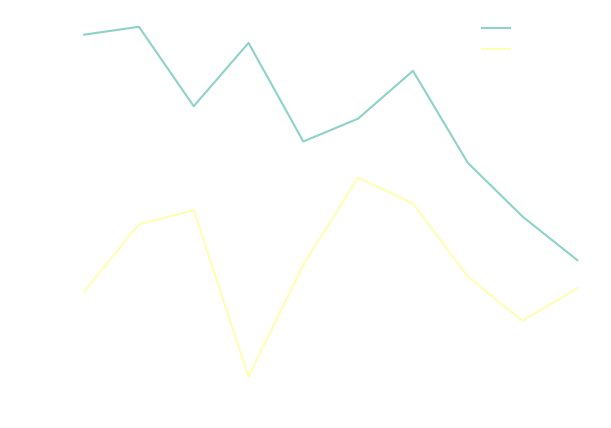

In [ ]:
losses = np.array(losses)
x = np.arange(losses.shape[0]) * i_log
with plt.style.context(pyplot_context):
    fig, axes = plt.subplots(figsize=(7,5))
    axes.plot(x, losses[:,0], label='train')
    axes.plot(x, losses[:,1], label='validation')
    axes.patch.set_alpha(plot_alpha)
    fig.patch.set_alpha(plot_alpha)
    axes.legend(frameon=False)

Save the model and optionally copy to google drive

In [ ]:
torch.save(model.state_dict(), 'flow_matching_model_transformer.pt') # Save with a new name
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/flow/', exist_ok=True)
!cp flow_matching_model_transformer.pt "/content/drive/MyDrive/Colab Notebooks/flow/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Flow Model Evaluation

### Model Sampling

Here some things about how sampling works.

In [ ]:
def do_flow_matching_sampling(model, x_1, num_sampling_steps, y=None): # y can be None for unconditional
    x_t = torch.clone(x_1) # Start from noise (x_1 at t=1)
    dt = 1.0 / num_sampling_steps

    model.eval()
    with torch.no_grad():
        for i in range(num_sampling_steps):
            t_float_current = 1.0 - i * dt  # Current time t for x_t

            # Ensure time tensors match the batch size and expected shape for the model
            t_current_tensor = t_float_current * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

            # RK4 steps for backward integration
            # k1 = dt * v(x_t, t)
            v1 = model(x_t, t_current_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k1 = v1 * dt

            # k2 = dt * v(x_t - 0.5 * k1, t - 0.5 * dt)
            x_k2_input = x_t - 0.5 * k1
            t_k2_float = t_float_current - 0.5 * dt
            t_k2_tensor = t_k2_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v2 = model(x_k2_input, t_k2_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k2 = v2 * dt

            # k3 = dt * v(x_t - 0.5 * k2, t - 0.5 * dt)
            x_k3_input = x_t - 0.5 * k2
            t_k3_float = t_float_current - 0.5 * dt # Same time as t_k2_float
            t_k3_tensor = t_k3_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v3 = model(x_k3_input, t_k3_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k3 = v3 * dt

            # k4 = dt * v(x_t - k3, t - dt)
            x_k4_input = x_t - k3
            t_k4_float = t_float_current - dt
            t_k4_tensor = t_k4_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v4 = model(x_k4_input, t_k4_tensor.squeeze(-1).unsqueeze(-1).unsqueeze(-1), y)
            k4 = v4 * dt

            # Update x_t using the RK4 formula for backward integration
            x_t = x_t - (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    return x_t

### Fréchet inception distance

The Fréchet distance is a measure of simlarity of two distributions. For two multidimensional Gaussian distributions, the distance is calculated as,
$$
d_F = \left| \mu_A - \mu_B \right|^2 + tr( \Sigma_A + \Sigma_B - 2 \sqrt{\Sigma_A \Sigma_B} )
$$
The Fréchet *inception* distance compares the output of the last layer before the classification layer of [inceptionv3](https://en.wikipedia.org/wiki/Inceptionv3). Here, instead, we use a much simplified classifier.

In [ ]:
class Classifier(torch.nn.Module):
    def __init__(self, num_output_classes=10): # Added num_output_classes for flexibility
        super(Classifier, self).__init__()

        self.layers = torch.nn.Sequential(
            # Input channels will be 3 for Flickr RGB images (if we train a classifier on full images)
            # If we train classifier on latents, this needs rethinking.
            # For now, assuming classifier trained on latent space, so input channels should match latent_channels
            torch.nn.Conv2d(latent_channels, 8, 3, padding='same'), # Changed from 1 to latent_channels
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            # 8x(latent_res/2)x(latent_res/2)
            torch.nn.Conv2d(8, 16, 3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            # 16x(latent_res/4)x(latent_res/4)
            torch.nn.Conv2d(16, 32, 3, padding='same'),
            torch.nn.ReLU(),
            # The AvgPool2d size needs to be adjusted based on latent_resolution
            # If latent_resolution is 8, (8/4=2). If latent_resolution is 4, (4/4=1)
            torch.nn.AvgPool2d(latent_resolution // 4, latent_resolution // 4), # Adjusted pool size

            # 32x(latent_res/4 / (latent_res/4))x(latent_res/4 / (latent_res/4)) = 32x1x1
            torch.nn.Flatten(),
            torch.nn.Dropout(),
        )

        # The linear layer input needs to match the flattened output of the conv layers
        # For latent_resolution=8, it would be 32*2*2 = 128. If latent_resolution=4, it's 32*1*1 = 32.
        linear_input_features = 32 * (latent_resolution // 4) * (latent_resolution // 4) # Adjust input size

        self.classification_layer = torch.nn.Sequential(
            torch.nn.Linear(linear_input_features, num_output_classes),
        )

classifier = Classifier(num_output_classes=1) # For unconditional FID, we don't need classification, or set to 1
classifier = classifier.to(device)

If your Classifier is saved, you can load it from your google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!cp "/content/drive/MyDrive/Colab Notebooks/classifier/classifier.pt" .
classifier.load_state_dict(torch.load('classifier.pt', map_location=device))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<All keys matched successfully>

신규로 Classifier 학습

In [ ]:
optimizer = torch.optim.Adam(classifier.parameters(), learning_rate)

i_log = 10
num_batches = int(math.ceil(lat_train.shape[0] / batch_size))
num_batches_val = int(math.ceil(lat_val.shape[0] / batch_size))

# Removed y_train and y_val from device, as classifier training is optional for unconditional FID

losses = []
# This training loop for the classifier is designed for MNIST and its labels.
# If we want to use FID for Flickr images, we typically don't train a classifier
# on the generated latents for classification accuracy in the same way as MNIST.
# FID usually works by comparing feature distributions from a pre-trained, high-quality classifier.
# For now, I will comment out this training loop as it's not directly applicable to Flickr.
# If you intend to classify Flickr images, you would need to define appropriate labels and
# potentially retrain a robust classifier.
print("Classifier training loop commented out as it was designed for MNIST labels.")
# for i in range(num_epochs):
#     classifier.train()
#     train_ids = torch.randperm(lat_train.shape[0])
#     average_loss = 0.0
#     for bid in range(num_batches):
#
#         with torch.no_grad():
#             batch_ids = train_ids[bid*batch_size:(bid+1)*batch_size]
#             x = lat_train[batch_ids,...].to(device) # Use latents, not original images
#             # y = y_train[batch_ids,...] # This would require labels for Flickr latents
#             # y = y.to(device)
#
#         # If we don't have y labels for Flickr, this cross_entropy loss won't work.
#         # y_pred = classifier(x)
#         # loss = cross_entropy(y_pred, y)
#         loss = torch.tensor(0.0) # Placeholder loss if no labels
#
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#
#         with torch.no_grad():
#             average_loss += loss.cpu().numpy() / num_batches
#
#     if (i + 1) % i_log == 0:
#         classifier.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for bid in range(num_batches_val):
#                 x = lat_val[bid*batch_size:(bid+1)*batch_size,...].to(device)
#                 # y = y_val[bid*batch_size:(bid+1)*batch_size,...].to(device)
#                 # y_pred = classifier(x)
#                 # loss = cross_entropy(y_pred, y)
#                 loss = torch.tensor(0.0) # Placeholder loss
#                 val_loss += loss.cpu().numpy()
#
#         val_loss /= num_batches_val
#         losses.append([average_loss, val_loss])
#         print(f'Epoch {i} loss = {average_loss}, val_loss = {val_loss}')


Epoch 9 loss = 0.07109985500574112, val_loss = 0.06946387141942978
Epoch 19 loss = 0.060401320457458496, val_loss = 0.06524866074323654
Epoch 29 loss = 0.05704311653971672, val_loss = 0.06439075618982315
Epoch 39 loss = 0.05209057778120041, val_loss = 0.06544092297554016
Epoch 49 loss = 0.047258708626031876, val_loss = 0.06303383409976959
Epoch 59 loss = 0.04747723788022995, val_loss = 0.06634481251239777
Epoch 69 loss = 0.046354182064533234, val_loss = 0.05711584910750389
Epoch 79 loss = 0.0436905100941658, val_loss = 0.06363432854413986
Epoch 89 loss = 0.041648756712675095, val_loss = 0.06037016212940216
Epoch 99 loss = 0.03899851813912392, val_loss = 0.055735182017087936
Epoch 109 loss = 0.03952137753367424, val_loss = 0.06457993388175964
Epoch 119 loss = 0.03916054964065552, val_loss = 0.060826532542705536
Epoch 129 loss = 0.03744611144065857, val_loss = 0.05886342376470566
Epoch 139 loss = 0.03636690601706505, val_loss = 0.05689403787255287
Epoch 149 loss = 0.03893045336008072, va

In [ ]:
torch.save(classifier.state_dict(), 'classifier.pt')
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/classifier/', exist_ok=True)
!cp classifier.pt "/content/drive/MyDrive/Colab Notebooks/classifier/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Classifier의 성능 평가

In [ ]:
classifier.eval()
# This accuracy evaluation is also based on MNIST labels.
# For FID on Flickr, we'd typically skip this or use a different metric.
print("Classifier accuracy evaluation commented out as it was designed for MNIST labels.")
# with torch.no_grad():
#     y_val_pred = classifier(lat_val.to(device)).cpu().numpy() # Use lat_val
#
# accuracy = np.mean(np.argmax(y_val_pred, axis=-1) == y_val.cpu().numpy())
# print(f'Model accuracy: {100.0 * accuracy:.2f}%')

Model accuracy: 99.20%


Let us use the Flow Matching model to generate a synthetic dataset with size equal to the validation set.

In [ ]:
batch_size_eval = 1024
num_batches_val = int(math.ceil(lat_val.shape[0] / batch_size_eval))
num_sampling_steps = 50 # Number of steps for ODE solver

x_gen = [] # Flow Matching generated images
x_gen_vae = [] # VAE generated images from random noise

with torch.no_grad():
    model.eval() # Flow Matching model
    decoder.eval() # VAE decoder

    for bi in tqdm(range(num_batches_val), desc="Generating images"):
        size = batch_size_eval
        if bi == num_batches_val - 1:
            size = lat_val.shape[0] - bi * batch_size_eval

        eval_shape = (size,) + latent_shape
        N = torch.normal(0, 1, eval_shape, device=device) # Initial noise for Flow Matching

        # For unconditional generation, y=None
        pred_flow_matching_latents = do_flow_matching_sampling(model, N, num_sampling_steps, y=None)

        # Decode Flow Matching generated latents to images
        # Denormalize from [-1, 1] to [0, 1] for potential plotting/saving
        pred_flow_matching_images = ((decoder(pred_flow_matching_latents) / 2.0) + 0.5).permute(0, 2, 3, 1).cpu().numpy()
        x_gen.append(pred_flow_matching_images)

        # Generate images from VAE by sampling random noise directly into latent space
        random_vae_latents = torch.normal(0, 1.0, size=(size,) + latent_shape, device=device)
        # Denormalize VAE generated images from [-1, 1] to [0, 1]
        pred_vae_images = ((decoder(random_vae_latents) / 2.0) + 0.5).permute(0, 2, 3, 1).cpu().numpy()
        x_gen_vae.append(pred_vae_images)

x_gen     = np.concatenate(x_gen)
x_gen_vae = np.concatenate(x_gen_vae)

We will now use the classifier to evaluate the layer before classification for our generated dataset, as well as for the validation and training dataset. Note that this classifier was originally designed for MNIST latents; its utility for Flickr latents might be limited unless retrained or adapted.

In [ ]:
classifier.eval()
with torch.no_grad():
    # Use lat_val (Flickr latents) for validation data features
    latent_val = classifier.layers(lat_val.to(device))

    # Use lat_train (Flickr latents) for training data features
    latent_train = classifier.layers(lat_train.to(device))

    # Use x_gen (Flow Matching generated latents) for generated data features
    # Note: x_gen now contains decoded images, not latents.
    # We need to re-encode them or pass the latents directly if we want FID on latents.
    # For this FID calculation, we should use the *latents* from the generation process.
    # Let's adjust EqNwALHe8glY to store latents.

    # Re-running the generation part to store latents for FID calculation correctly
    print("Re-generating latents for FID calculation...")
    x_gen_fid_latents = []
    x_gen_vae_fid_latents = []
    for bi in tqdm(range(num_batches_val), desc="Re-generating latents for FID"):
        size = batch_size_eval
        if bi == num_batches_val - 1:
            size = lat_val.shape[0] - bi * batch_size_eval
        eval_shape = (size,) + latent_shape
        N = torch.normal(0, 1, eval_shape, device=device)

        pred_flow_matching_latents = do_flow_matching_sampling(model, N, num_sampling_steps, y=None)
        x_gen_fid_latents.append(pred_flow_matching_latents)

        random_vae_latents = torch.normal(0, 1.0, size=(size,) + latent_shape, device=device)
        x_gen_vae_fid_latents.append(random_vae_latents)

    latent_gen = classifier.layers(torch.cat(x_gen_fid_latents).to(device))
    latent_gen_vae = classifier.layers(torch.cat(x_gen_vae_fid_latents).to(device))

    latent_rand = torch.randn(latent_gen.shape, device=device)
    mu    = torch.std(latent_train, dim=0)
    sigma = torch.mean(latent_train, dim=0)
    latent_rand = latent_rand * mu + sigma

Applying the classification layer to the latent variables. Since we are doing unconditional generation for Flickr and the classifier was originally for MNIST, these 'labels' are not meaningful as class predictions for Flickr images. They are simply the output of the classifier's last layer before softmax.

In [ ]:
# These labels are from a classifier possibly trained on MNIST and are not meaningful for Flickr.
# They are just the output of the classifier's final layer (before softmax).
# The accuracy calculation was also for MNIST, so it's not applicable directly here.
labels_gen     = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_gen), dim=-1), dim=-1).cpu().numpy()
labels_gen_vae = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_gen_vae), dim=-1), dim=-1).cpu().numpy()
labels_val     = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_val), dim=-1), dim=-1).cpu().numpy()
labels_train   = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_train), dim=-1), dim=-1).cpu().numpy()
labels_rand    = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_rand), dim=-1), dim=-1).cpu().numpy()

Let's plot a histogram of these 'pseudo-labels' for the generated and validation sets. Keep in mind these are outputs from a classifier that was potentially trained on MNIST, so their interpretation for Flickr is limited.

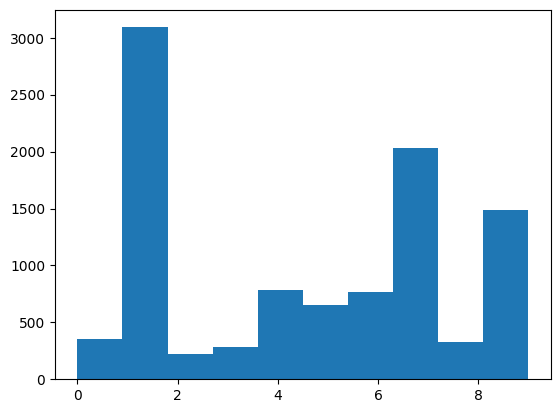

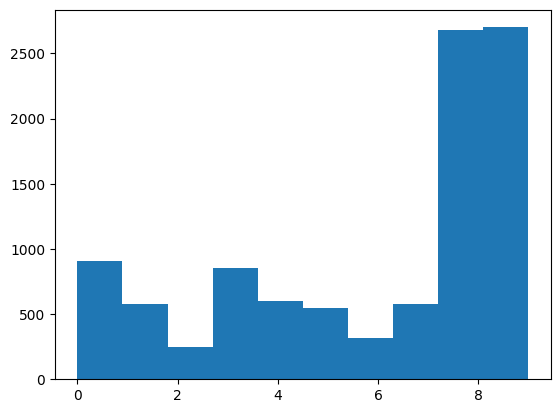

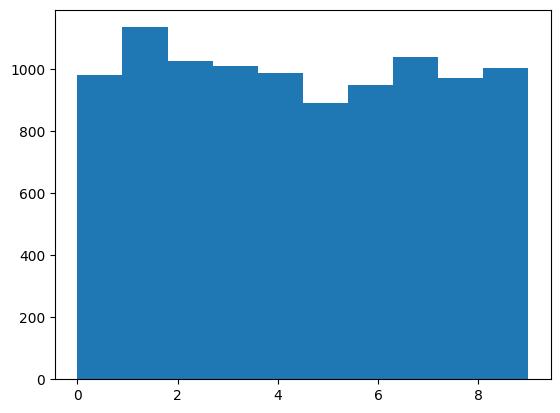

In [ ]:
plt.hist(labels_gen_vae)
plt.show()
plt.hist(labels_gen)
plt.show()
plt.hist(labels_val)
plt.show()

That's not bad, but there is definitely a difference there. Let us now evaluate the Fréchet distance!

In [ ]:
def frechet_distance(x_a, x_b):
    mu_a    = np.mean(x_a, axis=0)
    sigma_a = np.cov(x_a.T)
    mu_b    = np.mean(x_b, axis=0)
    sigma_b = np.cov(x_b.T)

    diff = mu_a - mu_b
    covmean = scipy.linalg.sqrtm(sigma_a @ sigma_b)
    return np.sum(diff**2) + np.trace(sigma_a + sigma_b - 2.0 * covmean)

In [ ]:
latent_val     = latent_val.cpu().numpy()
latent_rand    = latent_rand.cpu().numpy()
latent_gen     = latent_gen.cpu().numpy()
latent_gen_vae = latent_gen_vae.cpu().numpy()
latent_train   = latent_train.cpu().numpy()

In [ ]:
print('Random:    ', frechet_distance(latent_rand, latent_val))
print('VAE:       ', frechet_distance(latent_gen_vae, latent_val))
print('Flow Matching: ', frechet_distance(latent_gen, latent_val))
print('Validation:', frechet_distance(latent_val, latent_train))

/tmp/ipykernel_15476/3532828688.py:8: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = scipy.linalg.sqrtm(sigma_a @ sigma_b)


Random:     42.86458197034165
VAE:        34.00997590475748
Flow Matching:  25.662424262592673
Validation: 0.26918953220412906
